## Practical 10 
## Linear Regression in Machine Learning 

#### Task 01: Simple Linear Regression 

Model to predict a student’s score based on the number of hours they studied. 

In [ ]:
# Libraries to install:
    # pip install numpy
    # pip install pandas
    # pip install matplotlib
    # pip install scikit-learn

Step 1: Import Libraries 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression 
# from sklearn.metrics import mean_squared_error, r2_score 

Step 2: Create Sample Dataset 

Dataframe is like a table. It stores data in rows and columns

In [2]:
# Sample dataset: Hours studied vs Exam scores 
data = { 
'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 
'Scores': [35, 40, 50, 55, 60, 65, 70, 75, 85, 95] 
} 
df = pd.DataFrame(data) # Create a DataFrame from the dataset
print(df.head())

   Hours  Scores
0      1      35
1      2      40
2      3      50
3      4      55
4      5      60


Step 3: Visualize the Data

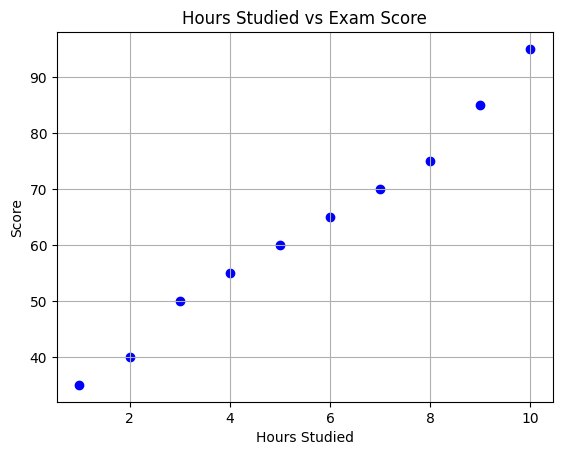

In [3]:
plt.scatter(df['Hours'], df['Scores'], color='blue') 
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied') 
plt.ylabel('Score') 
plt.grid(True) # Add grid for better visibility 
plt.show() 

Step 4: Prepare the Data 

X (Feature / Input) - This is what you give to the model. It’s a 2D array

y (Target / Output) - This is what the model tries to predict. It’s a 1D array

In [4]:
X = df[['Hours']]  # Feature (2D array) 
y = df['Scores']   # Target (1D array)

Step 5: Train the Model

In [5]:
model = LinearRegression() # Create a Linear Regression model
model.fit(X, y) # Train the model The model looks at:X → Hours studied y → Scores. It tries to find the best relationship between them

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Step 6: View the Learned Coefficients 

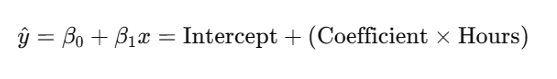

In [6]:
print("Intercept (β₀):", model.intercept_) # This is the point where the line crosses the y-axis, representing the expected score when hours studied is zero
print("Coefficient (β₁):", model.coef_[0]) # This is the slope(m) of the line, showing how much the score increases for each additional hour studied

Intercept (β₀): 28.666666666666657
Coefficient (β₁): 6.242424242424244


Step 7: Make Predictions

In [7]:
# Predict on training data 
y_pred = model.predict(X) 

# Predict on new data 
new_hours = [[6.5]] 
predicted_score = model.predict(new_hours) 
print("Predicted Score for 6.5 hours:", predicted_score[0]) # Give me the first value inside the array

Predicted Score for 6.5 hours: 69.24242424242425


f:\AI\Practical 10\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Step 8: Visualize the Regression Line 

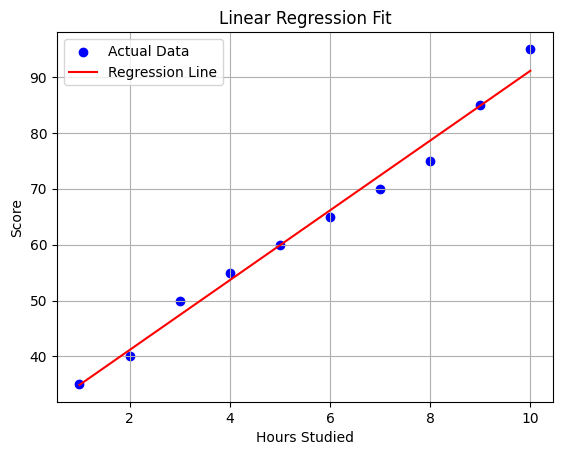

In [9]:
plt.scatter(X, y, color='blue', label='Actual Data') 
plt.plot(X, y_pred, color='red', label='Regression Line') 
plt.title('Linear Regression Fit')
plt.xlabel('Hours Studied') 
plt.ylabel('Score') 
plt.legend() 
plt.grid(True) 
plt.show() 

Step 9: Evaluate the Model 

In [10]:
from sklearn.metrics import mean_squared_error, r2_score 

mse = mean_squared_error(y, y_pred) 
r2 = r2_score(y, y_pred) 
print("Mean Squared Error (MSE):", mse) # Measures how far your predictions are from actual values
print("R² Score:", r2) # Shows how well your model explains the data

Mean Squared Error (MSE): 4.515151515151521
R² Score: 0.9861498419780628


#### Task 02

Predict student exam scores based on hours studied, using manual gradient descent. 

Step 1: Import Libraries

In [11]:
import numpy as np 
import matplotlib.pyplot as plt

Step 2: Create the Dataset

In [12]:
# Hours studied (x) and corresponding scores (y) 
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) 
y = np.array([35, 40, 50, 55, 60, 65, 70, 75, 85, 95]) 

Step 3: Define the Cost Function (Mean Squared Error)

A cost function - It measures the difference between actual values and predicted values.


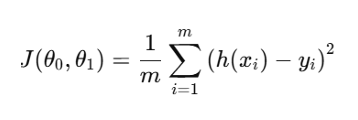

In [13]:
def compute_cost(X, y, theta0, theta1): 
    m = len(y) 
    predictions = theta0 + theta1 * X 
    cost = (1 / m) * np.sum((predictions - y) ** 2) 
    return cost 

Step 4: Implement Gradient Descent

Start with random values and slowly adjust them to reduce error (cost).
Model uses to learn the best values of θ₀ (intercept) and θ₁ (slope) step by step.

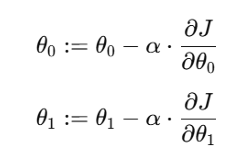

alpha - Learning rate (how big a step we take to reduce error)

Ex:

alpha = 0.0001 (Very tiny steps,Training is slow, Takes long time to reach minimum)

alpha = 1 (Steps are too big)

In [14]:
def gradient_descent(X, y, alpha=0.01, iterations=1000): 
    m = len(y) # Number of training points
    theta0 = 0 
    theta1 = 0 
    cost_history = [] 

    for i in range(iterations): 
        predictions = theta0 + theta1 * X #y= c + mx
        error = predictions - y 

        # Compute gradients 
        grad0 = (1 / m) * np.sum(error) 
        grad1 = (1 / m) * np.sum(error * X) 

        # Update parameters 
        theta0 -= alpha * grad0 
        theta1 -= alpha * grad1 

        # Track cost 
        cost = compute_cost(X, y, theta0, theta1) 
        cost_history.append(cost) 

        # Optionally print progress 
        if i % 100 == 0: # Print every 100 iterations
            print(f"Iteration {i}: Cost = {cost:.4f}, θ0 = {theta0:.4f}, θ1 = {theta1:.4f}") 

    return theta0, theta1, cost_history 

Step 5: Run Gradient Descent

In [16]:
theta0, theta1, cost_history = gradient_descent(X, y, alpha=0.01, iterations=1000) 
print(f"\nFinal Parameters: θ0 = {theta0:.4f}, θ1 = {theta1:.4f}") 

Iteration 0: Cost = 1685.3737, θ0 = 0.6300, θ1 = 3.9800
Iteration 100: Cost = 108.2806, θ0 = 6.6625, θ1 = 9.4031
Iteration 200: Cost = 72.6670, θ0 = 10.8339, θ1 = 8.8039
Iteration 300: Cost = 49.2764, θ0 = 14.2146, θ1 = 8.3183
Iteration 400: Cost = 33.9137, θ0 = 16.9544, θ1 = 7.9248
Iteration 500: Cost = 23.8238, θ0 = 19.1747, θ1 = 7.6059
Iteration 600: Cost = 17.1968, θ0 = 20.9742, θ1 = 7.3474
Iteration 700: Cost = 12.8443, θ0 = 22.4325, θ1 = 7.1379
Iteration 800: Cost = 9.9856, θ0 = 23.6143, θ1 = 6.9681
Iteration 900: Cost = 8.1081, θ0 = 24.5721, θ1 = 6.8306

Final Parameters: θ0 = 25.3414, θ1 = 6.7201


Step 6: Plot the Cost Function Over Iterations

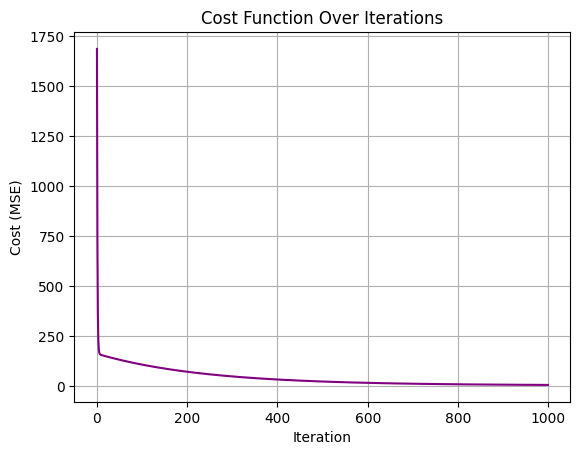

In [17]:
plt.plot(range(len(cost_history)), cost_history, color='purple') 
plt.title("Cost Function Over Iterations") 
plt.xlabel("Iteration") 
plt.ylabel("Cost (MSE)") 
plt.grid(True) 
plt.show() 

Step 7: Plot the Best Fit Line 

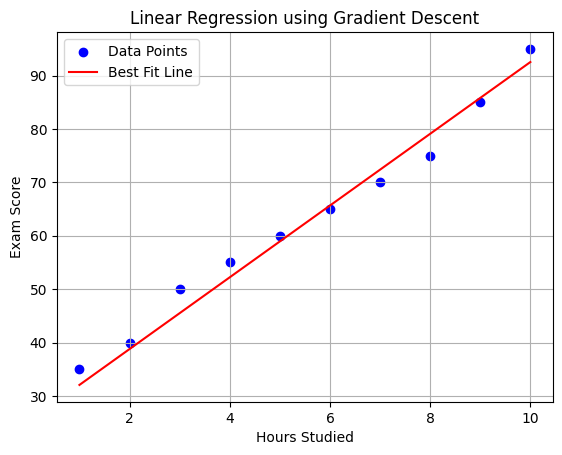

In [18]:
plt.scatter(X, y, color='blue', label='Data Points') 
plt.plot(X, theta0 + theta1 * X, color='red', label='Best Fit Line') 
plt.title("Linear Regression using Gradient Descent") 
plt.xlabel("Hours Studied") 
plt.ylabel("Exam Score") 
plt.legend() 
plt.grid(True) 
plt.show() 

Final Model Equation

In [19]:
def predict(x): 
    return theta0 + theta1 * x 

print("Predicted score for 6.5 hours:", predict(6.5)) 

Predicted score for 6.5 hours: 69.02183651721334


Build a model to predict an employee's salary based on their years of experience using a simple linear regression approach. 

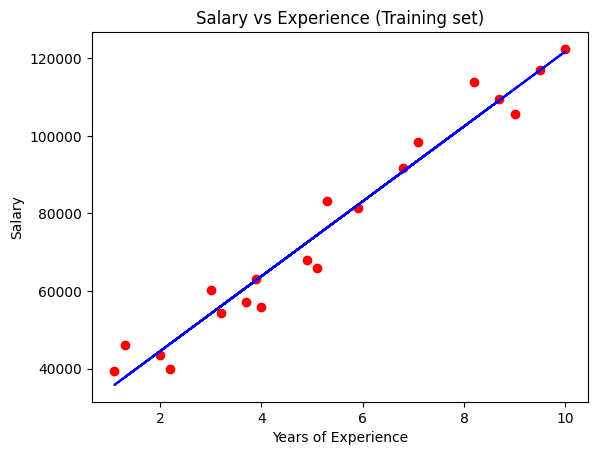

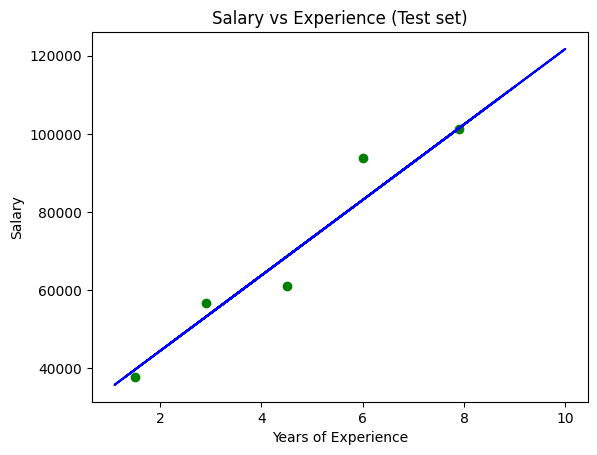

Predicted salary for 5 years of experience: $73452.73
Mean Squared Error: 37899222.37
R-squared: 0.93


In [20]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score 

# Load dataset 
dataset = pd.read_csv('Salary_Data.csv') 
X = dataset[['YearsExperience']].values # convert into a 2D array
y = dataset['Salary'].values #  convert into a 1D array

# Split into training and test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 
# random_state can be any number, and we use it to get the same train/test split every time we run the code.

# Train the linear regression model 
regressor = LinearRegression() 
regressor.fit(X_train, y_train) 

# Predict salaries for test data 
y_pred = regressor.predict(X_test) 

# Visualize training set results 
plt.scatter(X_train, y_train, color='red') 
plt.plot(X_train, regressor.predict(X_train), color='blue') 
plt.title('Salary vs Experience (Training set)') 
plt.xlabel('Years of Experience') 
plt.ylabel('Salary') 
plt.show() 

# Visualize test set results 
plt.scatter(X_test, y_test, color='green') 
plt.plot(X_train, regressor.predict(X_train), color='blue') 
plt.title('Salary vs Experience (Test set)') 
plt.xlabel('Years of Experience') 
plt.ylabel('Salary') 
plt.show() 

# Predict salary for a new input 
experience = np.array([[5]]) 
predicted_salary = regressor.predict(experience) 
print(f"Predicted salary for 5 years of experience: ${predicted_salary[0]:.2f}") 

# Evaluate the model 
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) 
print(f"Mean Squared Error: {mse:.2f}") 
print(f"R-squared: {r2:.2f}") 

### Task 03: Multiple Linear Regression in Python

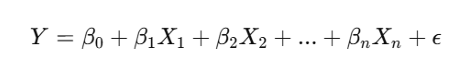

Step 1: Import Libraries

In [22]:
# pip install seaborn

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score

Step 2: Load Dataset

In [3]:
# Simulate a dataset 
np.random.seed(0) # get the same random numbers every time
X1 = np.random.rand(100) * 10 # 0-10 random numbers for feature X1
X2 = np.random.rand(100) * 5 # 0-5 random numbers for feature X2
noise = np.random.randn(100) # Random noise to make the data more realistic
Y = 3 + 2 * X1 + 4 * X2 + noise 

# Create DataFrame 
df = pd.DataFrame({'X1': X1, 'X2': X2, 'Y': Y}) 
df.head()

,X1,X2,Y
0,5.488135,3.389083,28.659237
1,7.151894,1.350040,21.624015
2,6.027634,3.675970,28.611679
3,5.448832,4.810943,32.703615
4,4.236548,1.243766,15.950126


Step 3: Exploratory Data Analysis (EDA)

               X1          X2           Y
count  100.000000  100.000000  100.000000
mean     4.727938    2.640409   22.927310
std      2.897540    1.390515    7.658095
min      0.046955    0.058570    5.607311
25%      2.058032    1.477986   17.035258
50%      4.674810    2.876206   24.166864
75%      6.844833    3.650117   28.640459
max      9.883738    4.994235   36.274043


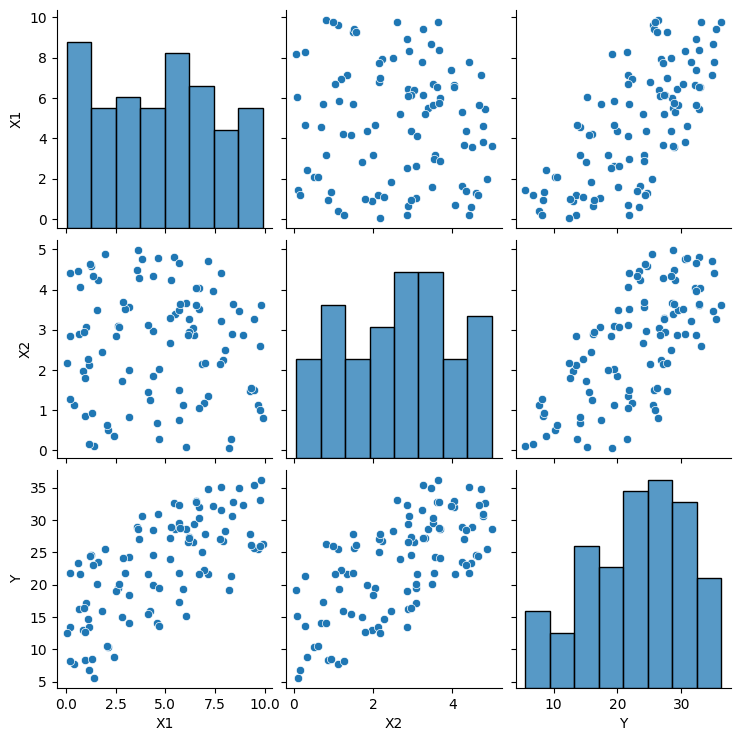

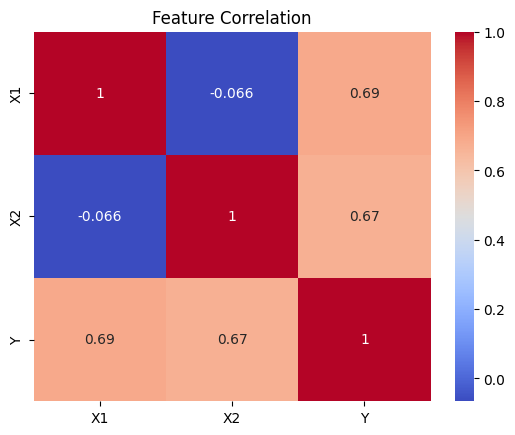

In [4]:
# Summary 
print(df.describe()) 

# Visualizations 
sns.pairplot(df) 
plt.show() 

# Correlation heatmap 
sns.heatmap(df.corr(), annot=True, cmap='coolwarm') 
plt.title('Feature Correlation') 
plt.show() 

Step 4: Prepare Data

In [5]:
# Features and target 
X = df[['X1', 'X2']] 
y = df['Y'] 

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 5: Train the MLR Model

In [6]:
# Initialize and train 
model = LinearRegression() 
model.fit(X_train, y_train) 

# Coefficients 
print("Intercept:", model.intercept_) # This is the expected value of Y when both X1 and X2 are zero
print("Coefficients:", model.coef_) # This shows how much Y changes for a one unit change in X1 and X2, respectively

Intercept: 3.2088160094990137
Coefficients: [1.94014258 3.97247376]


Step 6: Predict and Evaluate

In [ ]:
# Predict 
y_pred = model.predict(X_test) 

# Evaluation 
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) 

print("Mean Squared Error:", mse) 
print("R-squared:", r2)

Mean Squared Error: 0.725305441645198
R-squared: 0.9829925634007353


Step 7: Visualization

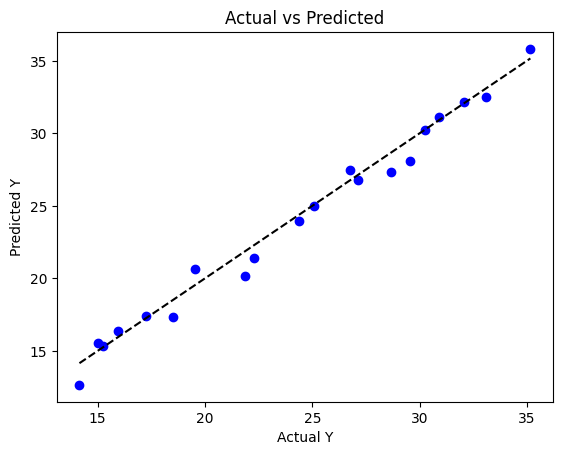

In [ ]:
# Actual vs Predicted 
plt.scatter(y_test, y_pred, color='blue') 
plt.xlabel('Actual Y') 
plt.ylabel('Predicted Y') 
plt.title('Actual vs Predicted') 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--') # black dashed line
plt.show() 